In [1]:
import json
import pickle
from collections import defaultdict

with open('../results/tracking_annotations.json', 'r') as f:
    data = json.load(f)

In [2]:
print(data['1']['0'])

[{'bbox': [1723, 350, 1919, 865], 'track_id': 0, 'group_id': 0}]


In [3]:
import glob
import os

video_folders = glob.glob('../SEKAI_900_3/videos_frames/*/')
video_folders.sort()
#print(video_folders)

jsons_path = '../SEKAI_900_3/jsons_step1'

for folder_id, folder in enumerate(video_folders):
    clip = folder.split('/')[-2]
    json_file = f'{jsons_path}/{clip}.json'
    
    with open(json_file, 'r') as f:
        json_data_s1 = json.load(f)

    #print(json_file)
    for frame in range(50):

        #print(frame)
        current_frame_info={}
        current_frame_info['frame_id'] = frame+1
        current_frame_info['detections'] = []

        #print(data[str(folder_id+1)][str(frame)])
        bboxes = [group.get('bbox',) for group in data[str(folder_id+1)][str(frame)]]
        ids = [group.get('track_id',) for group in data[str(folder_id+1)][str(frame)]]
        #print(len(bboxes))
        
        if bboxes[0] is None:
            json_data_s1['frames'].append(current_frame_info)
        else:
            for idx, box in zip(ids,bboxes):
                current_frame_info['detections'].append({'track_id': idx+1, 'bbox':box})
            json_data_s1['frames'].append(current_frame_info)
        

    jsons_path2 = jsons_path.replace('jsons_step1','jsons_step2')
    os.makedirs(jsons_path2, exist_ok=True)
    with open(f"{json_file.replace('jsons_step1','jsons_step2')}", "w") as f:
        json.dump(json_data_s1, f, indent=4)
        

In [4]:
!pwd

/home/artcs1/web_annotation_tool_v1/notebooks


In [5]:
# READ SBU ANNOTATIONS to generate GT
import json
import pickle
from collections import defaultdict

with open('../results/tracking_annotations.json', 'r') as f:
    data = json.load(f)

counter = 15

all_results = {}
map_r = {1:0, 21:1, 41:2}


#results = {}

#ann_frame = 1
#ann_frame = 21
ann_frame = 41

for annotations in data:

    idx = int(annotations)
    bboxes = data[annotations]
    #idx = annotations['videoIndex']

    if idx not in all_results:
       all_results[idx-1] = {}
    
    
    #print(idx)
    #print(ann_frame)
    groups = []
    map_group_members = defaultdict(list)
    #print(bboxes['0'])
    
    for idx_group, group in enumerate(bboxes[str(ann_frame)]):
        if len(group)>0:
            idx_person = group['track_id']
            x1, y1, x2, y2 = group['bbox']
            group_label = group['group_id']
            map_group_members[group_label+1].append(idx_person+1)
            #print(group_label)
            
            dc  = 1
            lvl = 1
            GT_list = [idx-1, 1, int(x1), int(y1), int(x2), int(y2), group_label+1, dc, lvl]
            str_to_be_added = [str(k) for k in GT_list]
            str_to_be_added = (" ".join(str_to_be_added))
            f = open('../results/gt_gold_sekai_'+str(ann_frame+1)+'.txt', "a+")
            f.write(str_to_be_added + "\r\n")
            f.close()

    
    groups = list(map_group_members.values())
    #print(groups)
    all_results[idx-1][str(0)] = groups

#print(all_results)
#print(all_results[2])

#print(all_results)

if all_results:
    save_path = f"../results/gt_gold_sekai_{ann_frame+1}.pkl"
    with open(save_path, "wb") as f:
        pickle.dump(all_results, f)


## TRACK COMPLETENESS / FRAGMENTATION QC

In [6]:
import json
import statistics as st
from collections import defaultdict

with open('../results/tracking_annotations.json', 'r') as f:
    data = json.load(f)

# A track's "span" is [first frame it appears, last frame it appears]. Frames
# missing *inside* that span are genuine tracking dropouts (SAM3 lost and later
# re-acquired the subject under the same track_id, or a frame carries an explicit
# '{}' placeholder). Frames outside the span (before first/after last appearance)
# are NOT gaps -- that's just the subject entering/leaving the shot, which is
# normal and shouldn't be counted as a tracking failure.

MIN_PRESENCE_FRAC = 0.10  # tracks present less than this fraction of the clip are
                           # treated as noise/spurious when computing "effective" counts

track_rows = []              # (clip_id, track_id, span, actual, gap, presence_frac)
clip_track_counts = []
clip_effective_track_counts = []

for clip_id, clip in data.items():
    n_frames = len(clip)
    if n_frames == 0:
        continue

    track_frames = defaultdict(set)
    for fk, boxes in clip.items():
        fidx = int(fk)
        for b in boxes:
            if b:  # skip explicit '{}' placeholder entries
                track_frames[b['track_id']].add(fidx)

    n_effective = 0
    for tid, frames_present in track_frames.items():
        first, last = min(frames_present), max(frames_present)
        span = last - first + 1
        actual = len(frames_present)
        gap = span - actual
        presence_frac = actual / n_frames
        track_rows.append((clip_id, tid, span, actual, gap, presence_frac))
        if presence_frac >= MIN_PRESENCE_FRAC:
            n_effective += 1

    clip_track_counts.append(len(track_frames))
    clip_effective_track_counts.append(n_effective)

n_tracks_total = len(track_rows)
presence_fracs = [r[5] for r in track_rows]
tracks_with_gap = [r for r in track_rows if r[4] > 0]

print(f"Total clips: {len(data)}   Total tracks: {n_tracks_total}")
print(f"Presence fraction (frames actually seen / frames in clip): "
      f"mean={st.mean(presence_fracs):.3f}  median={st.median(presence_fracs):.3f}")
n_full = sum(1 for p in presence_fracs if p == 1.0)
print(f"Fully-present tracks (visible in all 50 frames): {n_full} ({100*n_full/n_tracks_total:.1f}%)")

print("\nPresence-fraction distribution:")
buckets = [(0, 0.25), (0.25, 0.5), (0.5, 0.75), (0.75, 1.0), (1.0, 1.0001)]
labels = ["0-25%", "25-50%", "50-75%", "75-<100%", "100%"]
for (lo, hi), lab in zip(buckets, labels):
    cnt = sum(1 for p in presence_fracs if lo <= p < hi)
    print(f"  {lab:10s} {cnt:6d} ({100*cnt/n_tracks_total:.1f}%)")

print(f"\nTracks with an internal gap (real dropout, not just late entry/early exit): "
      f"{len(tracks_with_gap)} ({100*len(tracks_with_gap)/n_tracks_total:.1f}%)")
if tracks_with_gap:
    gap_vals = [r[4] for r in tracks_with_gap]
    print(f"  avg gap length among these: {st.mean(gap_vals):.2f} frames   median={st.median(gap_vals):.1f}")

print(f"\nTrack count per clip: mean={st.mean(clip_track_counts):.2f}  median={st.median(clip_track_counts)}")
print(f"Effective track count per clip (excluding tracks present <{int(MIN_PRESENCE_FRAC*100)}% of the clip): "
      f"mean={st.mean(clip_effective_track_counts):.2f}  median={st.median(clip_effective_track_counts)}")
inflation = st.mean(clip_track_counts) / st.mean(clip_effective_track_counts)
print(f"Raw track count is {inflation:.2f}x the filtered/effective count on average")
print("(most of the ~55% average presence fraction comes from tracks that simply span")
print(" less than the full clip -- entering/exiting the shot -- not from mid-track dropout;")
print(" the internal-gap rate above is the more direct tracking-failure signal.)")


Total clips: 900   Total tracks: 27603
Presence fraction (frames actually seen / frames in clip): mean=0.551  median=0.540
Fully-present tracks (visible in all 50 frames): 4193 (15.2%)

Presence-fraction distribution:
  0-25%        6641 (24.1%)
  25-50%       6182 (22.4%)
  50-75%       5495 (19.9%)
  75-<100%     5092 (18.4%)
  100%         4193 (15.2%)

Tracks with an internal gap (real dropout, not just late entry/early exit): 9541 (34.6%)
  avg gap length among these: 7.81 frames   median=5.0

Track count per clip: mean=30.67  median=25.0
Effective track count per clip (excluding tracks present <10% of the clip): mean=28.59  median=23.0
Raw track count is 1.07x the filtered/effective count on average
(most of the ~55% average presence fraction comes from tracks that simply span
 less than the full clip -- entering/exiting the shot -- not from mid-track dropout;
 the internal-gap rate above is the more direct tracking-failure signal.)


## GROUP SIZE DISTRIBUTION

In [7]:
import json
import statistics as st
from collections import defaultdict, Counter

with open('../results/tracking_annotations.json', 'r') as f:
    data = json.load(f)

# Group membership (group_id) is stable for a given track_id across a clip's frames
# (verified in the fragmentation QC above: 0/27603 tracks ever change group), so a
# group's size = the number of distinct track_ids that ever carry its group_id in
# that clip, regardless of which frame we look at.

group_sizes = []  # one entry per (clip, group_id): number of distinct track_ids in it

for clip_id, clip in data.items():
    group_tracks = defaultdict(set)  # group_id -> set of track_ids
    for fk, boxes in clip.items():
        for b in boxes:
            if b:
                group_tracks[b['group_id']].add(b['track_id'])
    for gid, tracks in group_tracks.items():
        group_sizes.append(len(tracks))

total_groups = len(group_sizes)
print(f"Total clips: {len(data)}")
print(f"Total groups: {total_groups}")
print(f"Group size: mean={st.mean(group_sizes):.2f}  median={st.median(group_sizes)}  max={max(group_sizes)}")

size_counts = Counter(group_sizes)
print("\nGroups by size:")
for size in range(1, 11):
    cnt = size_counts.get(size, 0)
    print(f"  size {size:2d}: {cnt:6d} ({100*cnt/total_groups:.1f}%)")
big = sum(v for k, v in size_counts.items() if k > 10)
print(f"  size >10: {big:6d} ({100*big/total_groups:.1f}%)")

solo = size_counts.get(1, 0)
multi = total_groups - solo
print(f"\nSolo ('groups' of 1 person): {solo} ({100*solo/total_groups:.1f}%)")
print(f"Actual multi-person groups (>=2): {multi} ({100*multi/total_groups:.1f}%)")
print("\n(Caveat: a track that gets fragmented into two track_ids mid-clip -- see the")
print(" fragmentation QC above -- would count as 2 members of the same group if both")
print(" pieces kept the same group_id, slightly inflating small-group counts.)")


Total clips: 900
Total groups: 22786
Group size: mean=1.21  median=1.0  max=18

Groups by size:
  size  1:  19239 (84.4%)
  size  2:   2732 (12.0%)
  size  3:    557 (2.4%)
  size  4:    176 (0.8%)
  size  5:     49 (0.2%)
  size  6:     11 (0.0%)
  size  7:      4 (0.0%)
  size  8:      5 (0.0%)
  size  9:      2 (0.0%)
  size 10:      6 (0.0%)
  size >10:      5 (0.0%)

Solo ('groups' of 1 person): 19239 (84.4%)
Actual multi-person groups (>=2): 3547 (15.6%)

(Caveat: a track that gets fragmented into two track_ids mid-clip -- see the
 fragmentation QC above -- would count as 2 members of the same group if both
 pieces kept the same group_id, slightly inflating small-group counts.)


## GROUP SIZE DISTRIBUTION BY CROWD DENSITY AND GLOBE REGION

In [8]:
import json
import pickle
import statistics as st
from collections import defaultdict, Counter

with open('../results/tracking_annotations.json', 'r') as f:
    data = json.load(f)

with open('clip_to_region.pkl', 'rb') as f:
    clip_to_region = pickle.load(f)

# tracking_annotations.json's clip_id ("1".."900") is the folder_id+1 enumeration
# over sorted(SEKAI_900_3/videos_frames/*) used earlier in this notebook, i.e.
# clip_id N == videoFolder "clip_{N:04d}". The crowd-density bucket used throughout
# agreement.ipynb (globalIndex % 3) was verified to equal (clip number % 3) for
# every finegrained doc, so it can be derived here without hitting Mongo.
bucket_names = {0: "Crowded", 1: "Scattered", 2: "Semi-crowded"}

rows = []  # (clip_id, group_size, bucket, region)
for clip_id, clip in data.items():
    n = int(clip_id)
    video_folder = f"clip_{n:04d}"
    bucket = bucket_names[n % 3]
    region = clip_to_region.get(video_folder, "Unknown")

    group_tracks = defaultdict(set)
    for fk, boxes in clip.items():
        for b in boxes:
            if b:
                group_tracks[b['group_id']].add(b['track_id'])
    for gid, tracks in group_tracks.items():
        rows.append((clip_id, len(tracks), bucket, region))

print(f"Total groups: {len(rows)}")
print(f"Clips with a resolved GLOBE region: {sum(1 for r in rows if r[3] != 'Unknown')} / {len(rows)}")


def summarize(subset, label):
    sizes = [r[1] for r in subset]
    n = len(sizes)
    c = Counter(sizes)
    solo = c.get(1, 0)
    print(f"{label:16s} groups={n:6d}  mean={st.mean(sizes):.2f}  solo={100*solo/n:5.1f}%  "
          f"size2={100*c.get(2,0)/n:5.1f}%  size3={100*c.get(3,0)/n:5.1f}%  "
          f"size4={100*c.get(4,0)/n:4.1f}%  size>=5={100*sum(v for k,v in c.items() if k>=5)/n:4.1f}%")


print("\n=== By crowd-density bucket ===")
for b in ["Crowded", "Semi-crowded", "Scattered"]:
    summarize([r for r in rows if r[2] == b], b)

print("\n=== By GLOBE cultural region (most clips first) ===")
region_order = sorted(set(r[3] for r in rows), key=lambda rg: -sum(1 for r in rows if r[3] == rg))
for rg in region_order:
    summarize([r for r in rows if r[3] == rg], rg)


Total groups: 22786
Clips with a resolved GLOBE region: 22786 / 22786

=== By crowd-density bucket ===
Crowded          groups= 13533  mean=1.20  solo= 85.8%  size2= 10.8%  size3=  2.4%  size4= 0.6%  size>=5= 0.4%
Semi-crowded     groups=  7159  mean=1.24  solo= 82.0%  size2= 14.1%  size3=  2.6%  size4= 1.0%  size>=5= 0.3%
Scattered        groups=  2094  mean=1.22  solo= 83.6%  size2= 12.8%  size3=  2.1%  size4= 1.2%  size>=5= 0.2%

=== By GLOBE cultural region (most clips first) ===
Anglo            groups=  5485  mean=1.19  solo= 85.5%  size2= 11.5%  size3=  2.1%  size4= 0.6%  size>=5= 0.4%
Latin Europe     groups=  2789  mean=1.26  solo= 82.0%  size2= 13.5%  size3=  3.1%  size4= 0.9%  size>=5= 0.5%
Confucian Asia   groups=  2549  mean=1.21  solo= 84.2%  size2= 12.2%  size3=  2.6%  size4= 0.8%  size>=5= 0.2%
African          groups=  2280  mean=1.13  solo= 90.5%  size2=  7.5%  size3=  1.2%  size4= 0.5%  size>=5= 0.3%
Germanic Europe  groups=  1988  mean=1.29  solo= 79.3%  size2= 15.9

## CROWD-DENSITY RATE BY GLOBE REGION

In [9]:
import pickle
from collections import defaultdict, Counter

with open('clip_to_region.pkl', 'rb') as f:
    clip_to_region = pickle.load(f)

# Crowd-density bucket derived from clip number % 3 (see previous cell for the
# verification against globalIndex % 3 in Mongo). This is a per-clip composition
# stat, independent of tracking_annotations.json.
bucket_names = {0: "Crowded", 1: "Scattered", 2: "Semi-crowded"}

region_bucket = defaultdict(Counter)
for video_folder, region in clip_to_region.items():
    n = int(video_folder.split('_')[1])
    bucket = bucket_names[n % 3]
    region_bucket[region][bucket] += 1

region_order = sorted(region_bucket.keys(), key=lambda r: -sum(region_bucket[r].values()))
print(f"{'Region':16s} {'n':>5s}  {'Crowded':>9s} {'Semi-crowded':>13s} {'Scattered':>10s}")
for r in region_order:
    c = region_bucket[r]
    total = sum(c.values())
    print(f"{r:16s} {total:5d}  {100*c['Crowded']/total:8.1f}% {100*c['Semi-crowded']/total:12.1f}% "
          f"{100*c['Scattered']/total:9.1f}%")


Region               n    Crowded  Semi-crowded  Scattered
Anglo              161      50.3%         32.3%      17.4%
Confucian Asia     114      34.2%         26.3%      39.5%
Latin Europe        90      50.0%         24.4%      25.6%
Middle East         85      17.6%         45.9%      36.5%
South-East Asia     80      26.2%         36.2%      37.5%
African             75      29.3%         45.3%      25.3%
Latin America       75      16.0%         40.0%      44.0%
Nordic Europe       72       1.4%         20.8%      77.8%
Eastern Europe      69      30.4%         26.1%      43.5%
Germanic Europe     69      55.1%         40.6%       4.3%
Other               10      50.0%         30.0%      20.0%


## GROUP SIZE DISTRIBUTION BY GLOBE REGION (stacked bar, tracking-based)

In [10]:
import json
import pickle
from collections import defaultdict

with open('../results/tracking_annotations.json', 'r') as f:
    data = json.load(f)

with open('clip_to_region.pkl', 'rb') as f:
    clip_to_region = pickle.load(f)

# clip_id ("1".."900") == folder_id+1 from sorted(SEKAI_900_3/videos_frames/*),
# i.e. clip_id N == videoFolder "clip_{N:04d}" (same convention used in the
# crowd-density cells above). Group membership is stable for a track_id across
# a clip's frames, so group size = number of distinct track_ids ever sharing
# that group_id in the clip (see GROUP SIZE DISTRIBUTION cell above).
region_group_size = defaultdict(list)

for clip_id, clip in data.items():
    video_folder = f"clip_{int(clip_id):04d}"
    region = clip_to_region.get(video_folder)
    if region is None:
        continue

    group_tracks = defaultdict(set)
    for fk, boxes in clip.items():
        for b in boxes:
            if b:
                group_tracks[b['group_id']].add(b['track_id'])

    for gid, tracks in group_tracks.items():
        if len(tracks) >= 2:  # exclude solo "individual" partitions
            region_group_size[region].append(len(tracks))

print({r: len(v) for r, v in region_group_size.items()})

{'Anglo': 796, 'Middle East': 292, 'Confucian Asia': 402, 'South-East Asia': 219, 'Latin Europe': 502, 'Eastern Europe': 325, 'Latin America': 183, 'African': 216, 'Other': 61, 'Germanic Europe': 411, 'Nordic Europe': 140}


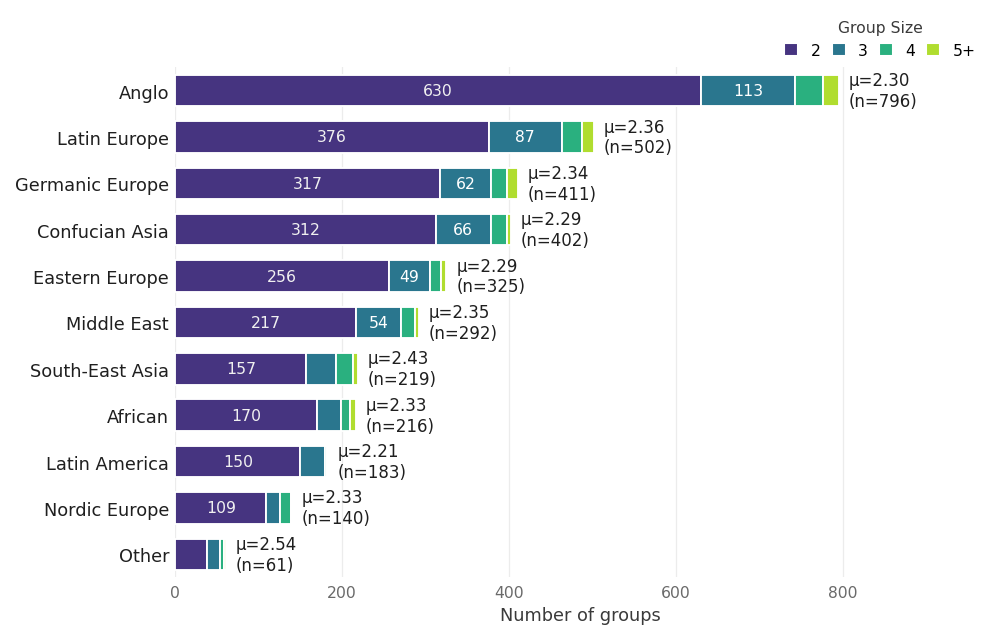

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

regions = {
    "AN": np.array(region_group_size["Anglo"]),
    "ME": np.array(region_group_size["Middle East"]),
    "CA": np.array(region_group_size["Confucian Asia"]),
    "SEA": np.array(region_group_size["South-East Asia"]),
    "LE": np.array(region_group_size["Latin Europe"]),
    "EE": np.array(region_group_size["Eastern Europe"]),
    "LA": np.array(region_group_size["Latin America"]),
    "OT": np.array(region_group_size["Other"]),
    "AF": np.array(region_group_size["African"]),
    "GE": np.array(region_group_size["Germanic Europe"]),
    "NE": np.array(region_group_size["Nordic Europe"]),
}
region_names = {
    "AN": "Anglo", "ME": "Middle East", "CA": "Confucian Asia", "SEA": "South-East Asia",
    "LE": "Latin Europe", "EE": "Eastern Europe", "LA": "Latin America", "OT": "Other",
    "AF": "African", "GE": "Germanic Europe", "NE": "Nordic Europe",
}

# region_group_size only ever contains sizes >=2 (singletons/"individual"
# partitions are filtered out upstream), so there is no "Score 1" bucket --
# start the score columns (and the legend/colors below) at size 2.
rows = []
for region, values in regions.items():
    unique, counts = np.unique(values, return_counts=True)
    count_dict = dict(zip(unique, counts))
    rows.append({
        "Region": region,
        "Score 2": count_dict.get(2, 0),
        "Score 3": count_dict.get(3, 0),
        "Score 4": count_dict.get(4, 0),
        "Score 5": sum(v for k, v in count_dict.items() if k >= 5),
    })
counts = pd.DataFrame(rows).set_index("Region")

score_values = pd.Series([2, 3, 4, 5], index=counts.columns)
means = counts.mul(score_values, axis=1).sum(axis=1) / counts.sum(axis=1)
totals = counts.sum(axis=1)
order = totals.sort_values(ascending=True).index
counts = counts.loc[order]; means = means.loc[order]; totals = totals.loc[order]

counts_display = counts.copy()
counts_display.index = [region_names[r] for r in counts.index]

colors = plt.cm.viridis(np.linspace(0.15, 0.88, 4))
fig, ax = plt.subplots(figsize=(7.2, 5.0), dpi=150)
fig.patch.set_facecolor("white")

xmax = totals.max() * 1.22
MIN_LABEL_FRAC = 0.05
left = np.zeros(len(counts_display))

for i, col in enumerate(counts.columns):
    vals = counts[col].values
    ax.barh(counts_display.index, vals, left=left, color=colors[i],
            edgecolor="white", linewidth=0.9, height=0.68)
    for j, v in enumerate(vals):
        if v / xmax >= MIN_LABEL_FRAC:
            ax.text(left[j] + v / 2, j, f"{int(v)}", ha="center", va="center",
                    color="white" if i >= 1 else "#f0f0f0", fontsize=7.5, fontweight="medium")
    left += vals

for i, region in enumerate(counts_display.index):
    ax.text(totals.iloc[i] + xmax * 0.012, i,
            f"μ={means.iloc[i]:.2f}\n(n={int(totals.iloc[i]):,})",
            va="center", ha="left", fontsize=8, color="#1f1f1f")

ax.set_xlim(0, xmax)
ax.set_xlabel("Number of groups", fontsize=8.5, color="#3a3a3a", labelpad=3)
ax.tick_params(axis="y", length=0, labelsize=8.5, colors="#1f1f1f", pad=3)
ax.tick_params(axis="x", length=0, labelsize=7.5, colors="#6a6a6a")
ax.set_axisbelow(True)
ax.xaxis.grid(True, color="#ececec", linewidth=0.6)
ax.yaxis.grid(False)
for s in ax.spines.values():
    s.set_visible(False)

legend_labels = ["2", "3", "4", "5+"]
handles = [mpatches.Patch(facecolor=colors[i], edgecolor="white", label=legend_labels[i]) for i in range(4)]
leg = ax.legend(handles=handles, title="Group Size", loc="lower right", bbox_to_anchor=(1.0, 1.0),
                 ncol=4, frameon=False, handlelength=0.9, handleheight=0.9, columnspacing=0.7,
                 fontsize=7.5, title_fontsize=7.5, borderaxespad=0.2)
leg.get_title().set_color("#3a3a3a")

ax.set_ylim(-0.5, len(counts_display) - 0.5)
plt.subplots_adjust(top=0.88, bottom=0.20, left=0.22, right=0.97)
plt.savefig("groupsize_dist_all_regions_tracking.pdf", bbox_inches="tight", pad_inches=0.05)
plt.show()